In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine

import scipy.stats as stats
from scipy.stats import ttest_ind

from dotenv import load_dotenv
import os


In [76]:
load_dotenv()



# MySQL connection
username=os.getenv("DB_USERNAME")
password=os.getenv("DB_PASSWORD")
host=os.getenv("DB_HOST")
port=os.getenv("DB_PORT")
database=os.getenv("DB")

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

In [77]:
df=pd.read_sql("Select * from vendor_sales_summary",engine)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrices,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080.0,3811251.60,284098.0,1.020384e+07,1345638.62,521998.40,68601.68,6.392587e+06,62.648846,1.958216,2.677293
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038.0,3804041.22,320494.0,9.638147e+06,1123024.74,588877.32,144929.24,5.834106e+06,60.531405,1.953779,2.533660
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407.0,3418303.68,374280.0,9.076241e+06,922280.30,687708.14,123780.22,5.657938e+06,62.337893,1.997151,2.655189
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682.0,3261197.94,400824.0,8.951946e+06,840100.02,736485.60,257032.07,5.690748e+06,63.569954,1.987406,2.744987
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109.0,3023206.01,271676.0,8.446215e+06,1091556.56,499175.66,257032.07,5.423009e+06,64.206382,1.967113,2.793794


In [78]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,10650.649458,18753.519148,2.000000,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,18039.228769,12662.187074,58.000000,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,24.385303,109.269375,0.360000,6.840000,10.455000,19.482500,5.681810e+03
ActualPrices,10692.0,35.643671,148.246016,0.490000,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,847.360550,664.309212,50.000000,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3140.886831,11095.086769,1.000000,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,30106.693372,123067.799627,0.710000,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,6154.964272,21905.702782,0.000000,66.000000,522.000000,3858.500000,6.698780e+05
TotalSalesDollars,10692.0,84478.148838,335310.531968,0.000000,1458.440000,10596.090000,56793.830000,1.020384e+07
TotalSalesPrice,10692.0,37587.567254,89905.546771,0.000000,579.420000,5715.600000,32119.125000,1.345639e+06


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10692 entries, 0 to 10691
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorNumber           10692 non-null  int64  
 1   VendorName             10692 non-null  object 
 2   Brand                  10692 non-null  int64  
 3   Description            10692 non-null  object 
 4   PurchasePrice          10692 non-null  float64
 5   ActualPrices           10692 non-null  float64
 6   Volume                 10692 non-null  float64
 7   TotalPurchaseQuantity  10692 non-null  float64
 8   TotalPurchaseDollars   10692 non-null  float64
 9   TotalSalesQuantity     10692 non-null  float64
 10  TotalSalesDollars      10692 non-null  float64
 11  TotalSalesPrice        10692 non-null  float64
 12  TotalExciseTax         10692 non-null  float64
 13  FreightCost            10692 non-null  float64
 14  GrossProfit            10692 non-null  float64
 15  Pr

In [80]:
numerical_features=df.select_dtypes(include=np.number)

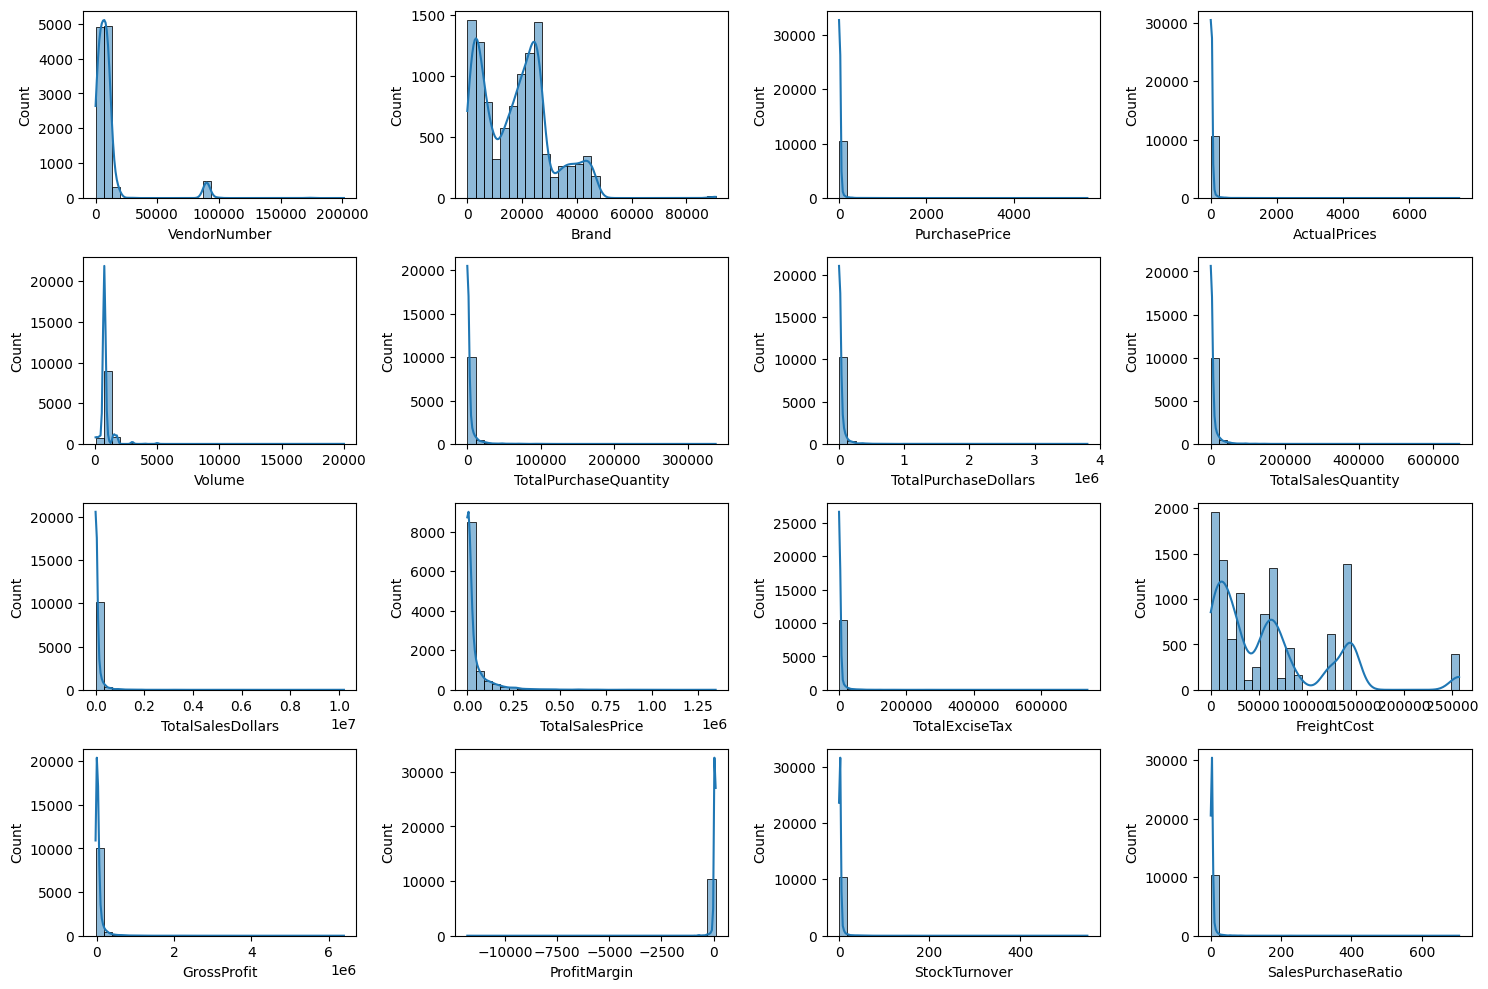

In [81]:

plt.figure(figsize=(15,10))
for i,col in enumerate(numerical_features.columns):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col],kde=True,bins=30)
    
    

plt.tight_layout()
plt.show()

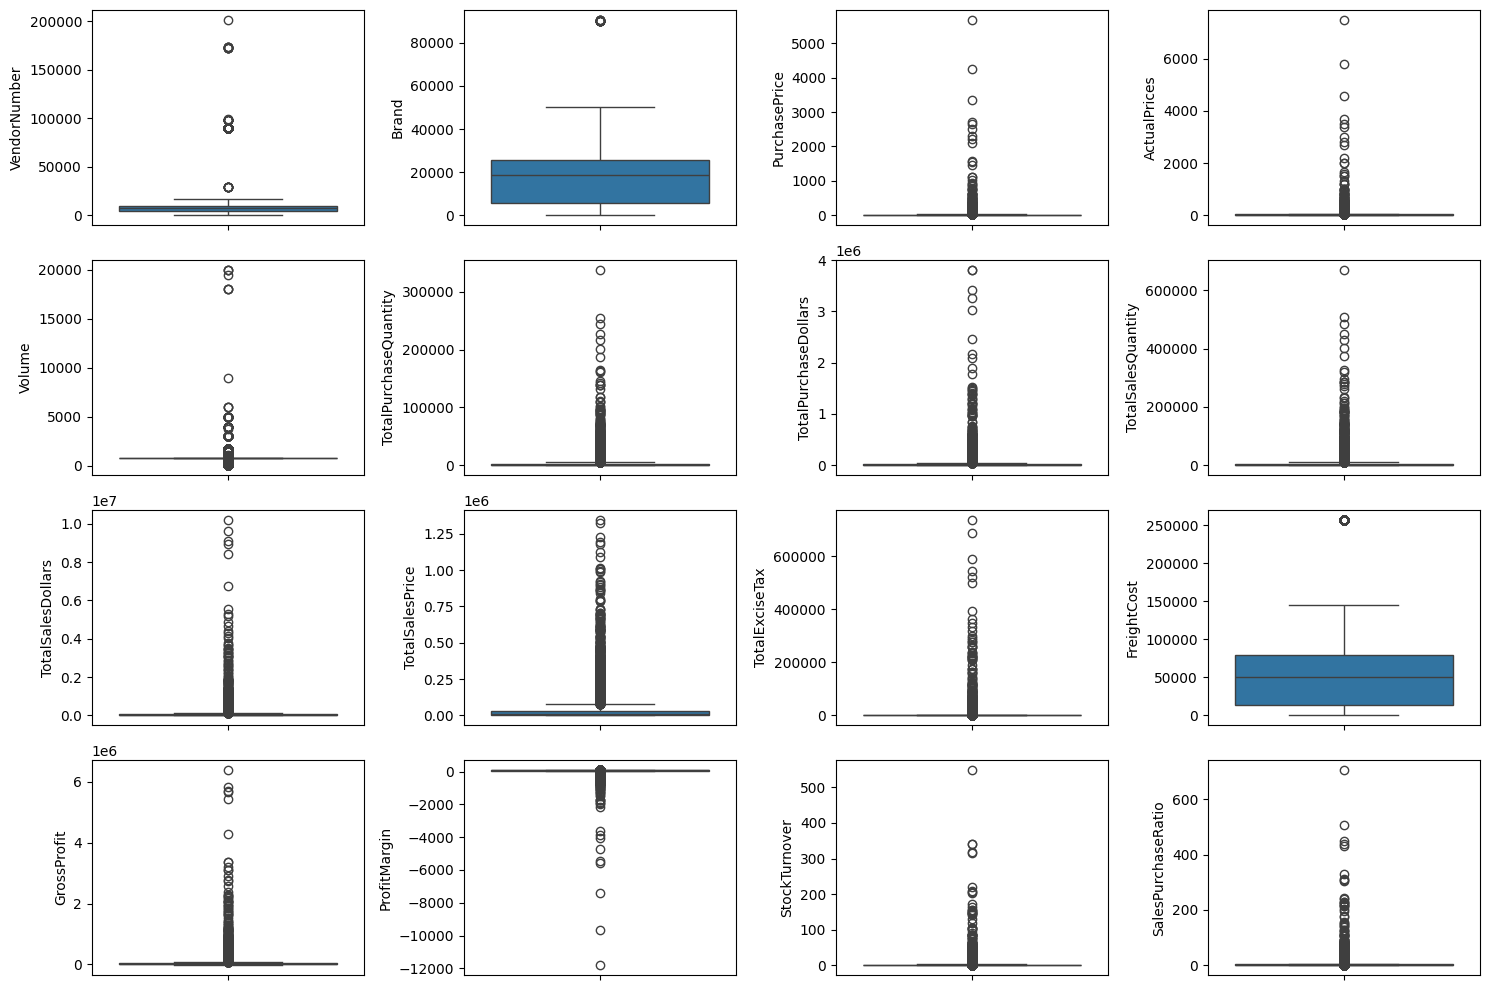

In [82]:

plt.figure(figsize=(15,10))
for i,col in enumerate(numerical_features.columns):
    plt.subplot(4,4,i+1)
    sns.boxplot(df[col])
    
    

plt.tight_layout()
plt.show()

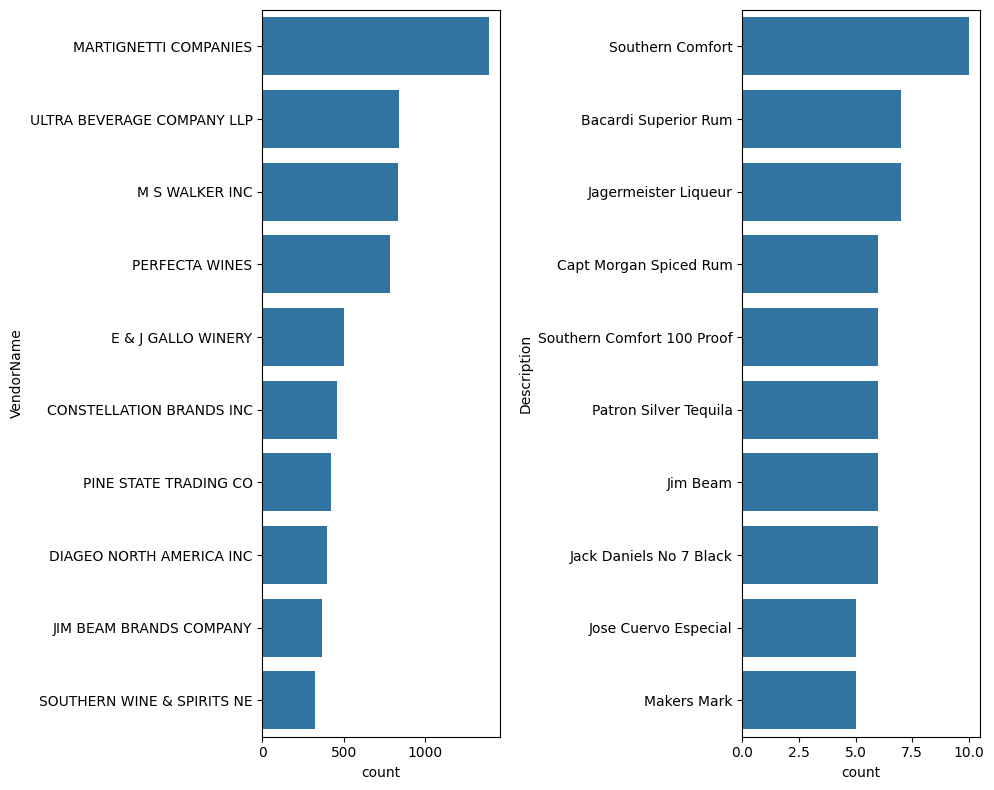

In [83]:
categorical_col=['VendorName','Description']


plt.figure(figsize=(10,8))
for i,col in enumerate(categorical_col):
    plt.subplot(1,2,i+1)
    sns.countplot(df[col],order=df[col].value_counts().index[:10]) #Top 10 category
    
    
plt.tight_layout()
plt.show()

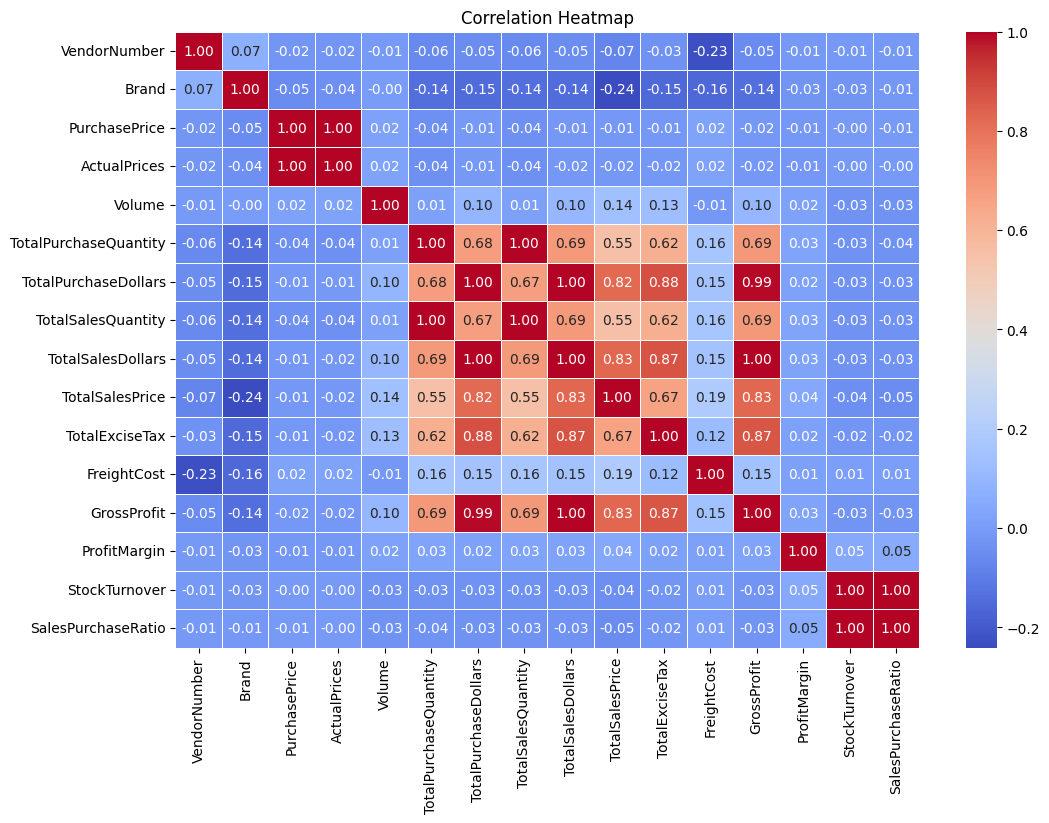

In [84]:
plt.figure(figsize=(12,8))
correlation_matrix=df[numerical_features.columns].corr()
sns.heatmap(correlation_matrix,annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

### Observations

#### Negative & zero values : 

* **Gross Profit** : Minimum value is -31730.240000, indicating loss.
* **Profit Margin** : Minimum value is -11815.319477, which suggests cases where revenue is zero or even lower than costs.
* **Total sales & sales dollars** : Minimum value is 0, means some products were purchased but never sold.

#### Outliers indicated by high standard deviations : 
* **Purchase & Actual prices** : The max values (5,681.81 & 7,499.99) are significantly higher than the mean (24.39 & 35.64), indicating potential premium products.
* **Freight Cost** : Huge variation, from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.
* **Stock Turnover** : Ranges from 0 to 274.5, implying some products sell extremely fast while other remain in stock. Value more than 1 indicates that sold quantity for that product is higher than purchased quantity due to either sales are being fulfilled from older stock.

#### other insights
* PurchasePrice has weak correlations with TotalSalesDollars(-0.012) and GrossProfit(-0.016), suggesting that price variations do not significantly impact sales revenue or profit.
* Strong correlation between TotalPurchaseQuantity and TotalSalesQuantity(0.999), confirming efficient inventory turnover.
* StockTurnover has weak negative correlations with both GrossProfit(-0.038) and ProfitMargin(-0.055), indicating that faster turnover does not necessarily result in higher profitability.

## Data Analysis


**Identify brands that needs promotional or pricing adjustments which exhibit lower sales performance but higher profit margins.**


In [85]:
def format_dollars(value):
    if value>=1_000_000:
        return f"{value/1_000_000:.2f}M"
    elif value>=1_000:
        return f"{value/1_000:.2f}K"
    else:
        return str(value)

In [86]:
brand_performance=df.groupby('Description').agg({
    'TotalSalesDollars':'sum',
    'ProfitMargin':'mean'
}).reset_index()

In [87]:
low_sales_threshold=brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold=brand_performance['ProfitMargin'].quantile(0.85)

In [88]:
high_margin_threshold

np.float64(78.30918315039251)

In [89]:
mask1=brand_performance['TotalSalesDollars']<=low_sales_threshold
mask2=brand_performance['ProfitMargin']>=high_margin_threshold

traget_brands=brand_performance[mask1 & mask2]

print("Brands with Low sales but high Profit margins : ")
display(traget_brands.sort_values('TotalSalesDollars'))

Brands with Low sales but high Profit margins : 


,Description,TotalSalesDollars,ProfitMargin
7777,Santa Rita Organic Svgn Bl,19.98,83.233233
2896,Debauchery Pnt Nr,23.16,82.987910
2537,Concannon Glen Ellen Wh Zin,31.90,91.724138
2677,Crown Royal Apple,55.72,94.903087
7818,Sauza Sprklg Wild Berry Marg,55.92,91.076538
...,...,...,...
8939,Tommasi Poggio Tufo Cab Svgn,539.46,87.394802
9229,Vigne A Porrona Rosso,545.58,98.412698
3980,Gifft Chardonnay,559.60,97.122945
5736,Mad Dogs & Englishmen Jumil,559.60,98.833095


In [90]:
brand_performance=brand_performance[brand_performance['TotalSalesDollars']<10000] # for better visualization

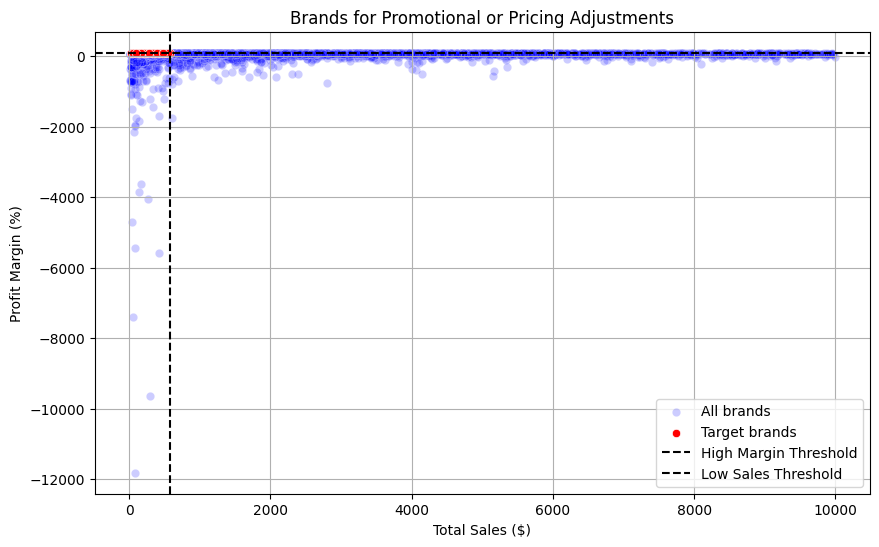

In [91]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=brand_performance,x='TotalSalesDollars',y='ProfitMargin',color='blue',label='All brands', alpha=0.2)
sns.scatterplot(data=traget_brands,x='TotalSalesDollars',y='ProfitMargin',color='red',label='Target brands')

plt.axhline(high_margin_threshold,linestyle='--',color='black',label="High Margin Threshold")
plt.axvline(low_sales_threshold,linestyle='--',color='black',label="Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

**Which vendors and brands demonstrate the highest sales performance ?**

In [92]:
top_vendors=df.groupby('VendorName')['TotalSalesDollars'].sum().nlargest(10)
top_product=df.groupby('Description')['TotalSalesDollars'].sum().nlargest(10)

In [93]:
top_vendors

VendorName
DIAGEO NORTH AMERICA INC      1.374797e+08
MARTIGNETTI COMPANIES         8.192024e+07
PERNOD RICARD USA             6.455909e+07
JIM BEAM BRANDS COMPANY       6.379724e+07
BACARDI USA INC               5.001073e+07
CONSTELLATION BRANDS INC      4.893427e+07
E & J GALLO WINERY            3.710755e+07
BROWN-FORMAN CORP             3.695322e+07
ULTRA BEVERAGE COMPANY LLP    3.560529e+07
M S WALKER INC                3.087213e+07
Name: TotalSalesDollars, dtype: float64

In [94]:
top_product

Description
Jack Daniels No 7 Black    1.592949e+07
Tito's Handmade Vodka      1.479932e+07
Grey Goose Vodka           1.441922e+07
Capt Morgan Spiced Rum     1.271264e+07
Absolut 80 Proof           1.248950e+07
Jameson Irish Whiskey      1.143152e+07
Ketel One Vodka            1.014017e+07
Baileys Irish Cream        8.300244e+06
Kahlua                     7.209717e+06
Tanqueray                  6.913396e+06
Name: TotalSalesDollars, dtype: float64

C:\Users\Ashish Panchal\AppData\Local\Temp\ipykernel_3384\283075839.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_vendors.index,x=top_vendors.values,palette="Blues_r")
C:\Users\Ashish Panchal\AppData\Local\Temp\ipykernel_3384\283075839.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_product.index,x=top_product.values,palette='Reds_r')


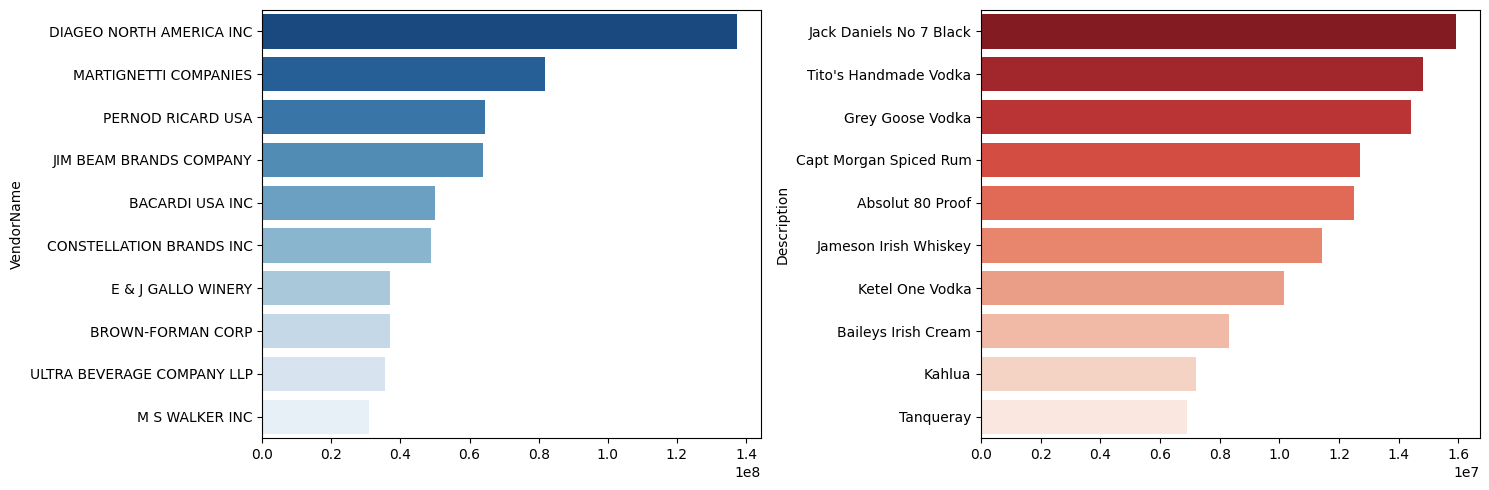

In [95]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
sns.barplot(y=top_vendors.index,x=top_vendors.values,palette="Blues_r")

plt.subplot(1,2,2)
sns.barplot(y=top_product.index,x=top_product.values,palette='Reds_r')

plt.tight_layout()
plt.show()

**Which vendors contribute the most to total purchase dollars?**

In [96]:
vendor_performance=df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars':'sum'
}).reset_index()

In [97]:
vendor_performance['PurchaseContribution%']=vendor_performance['TotalPurchaseDollars']/vendor_performance['TotalPurchaseDollars'].sum()*100

In [98]:
vendor_performance=round(vendor_performance.sort_values('PurchaseContribution%',ascending=False),2)

In [99]:
top_vendors=vendor_performance.head(10)

In [100]:
top_vendors["PurchaseContribution%"].sum()

np.float64(65.34)

* top 10 vendors has 65% contribution in purchase

In [101]:
top_vendors['Cumulative_Contribution%']=top_vendors['PurchaseContribution%'].cumsum()

C:\Users\Ashish Panchal\AppData\Local\Temp\ipykernel_3384\2851312941.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_vendors['Cumulative_Contribution%']=top_vendors['PurchaseContribution%'].cumsum()


In [102]:
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cumulative_Contribution%
28,DIAGEO NORTH AMERICA INC,50959796.85,86519873.09,1.374797e+08,15.83,15.83
63,MARTIGNETTI COMPANIES,27861690.02,54058545.62,8.192024e+07,8.66,24.49
50,JIM BEAM BRANDS COMPANY,24203151.05,39594091.27,6.379724e+07,7.52,32.01
74,PERNOD RICARD USA,24124091.56,40434996.78,6.455909e+07,7.49,39.50
8,BACARDI USA INC,17624378.72,32386352.86,5.001073e+07,5.48,44.98
23,CONSTELLATION BRANDS INC,15573917.90,33360350.56,4.893427e+07,4.84,49.82
14,BROWN-FORMAN CORP,13529433.08,23423790.12,3.695322e+07,4.20,54.02
114,ULTRA BEVERAGE COMPANY LLP,13210613.93,22394678.27,3.560529e+07,4.10,58.12
33,E & J GALLO WINERY,12289608.09,24817941.23,3.710755e+07,3.82,61.94
59,M S WALKER INC,10935817.30,19936315.22,3.087213e+07,3.40,65.34


C:\Users\Ashish Panchal\AppData\Local\Temp\ipykernel_3384\3518096017.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vendors['VendorName'], y=top_vendors['PurchaseContribution%'], palette='mako', ax=ax1)
C:\Users\Ashish Panchal\AppData\Local\Temp\ipykernel_3384\3518096017.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)


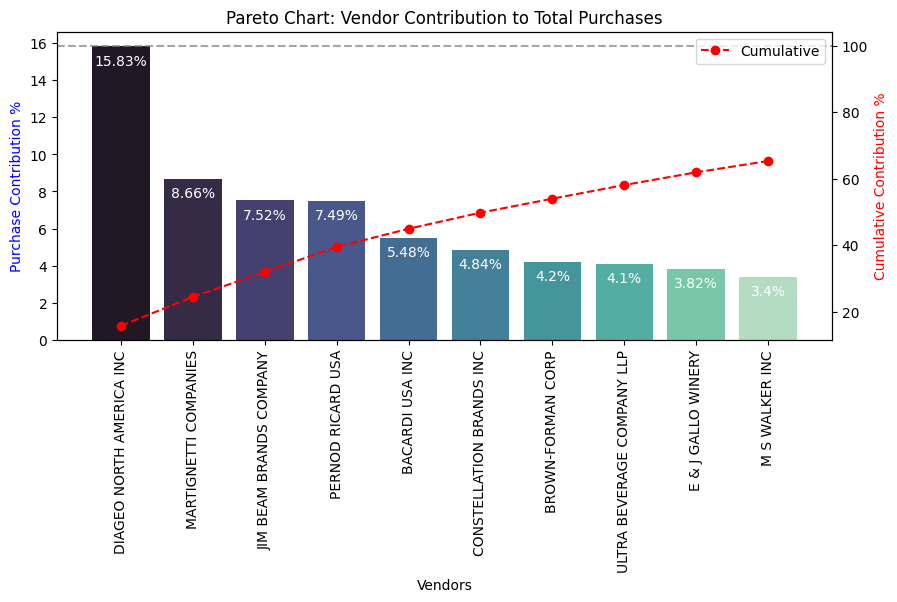

In [103]:
fig, ax1 = plt.subplots(figsize=(10, 4))

# Bar plot for Purchase Contribution
sns.barplot(x=top_vendors['VendorName'], y=top_vendors['PurchaseContribution%'], palette='mako', ax=ax1)
for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i, value - 1, str(value) + '%', ha='center', fontsize=10, color='white')

# Line Plot for Cumulative Contribution%
ax2 = ax1.twinx()
ax2.plot(
    top_vendors['VendorName'],                 # x (positional)
    top_vendors['Cumulative_Contribution%'],    # y (positional)
    color='red', marker='o', linestyle='dashed', label='Cumulative'
)

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')
plt.show()

**How much of total procurement is dependent on the top vendors?**

In [104]:
print(f"Total Purchase Contribution of top 10 vendors is {round(top_vendors['PurchaseContribution%'].sum(),2)} %")

Total Purchase Contribution of top 10 vendors is 65.34 %


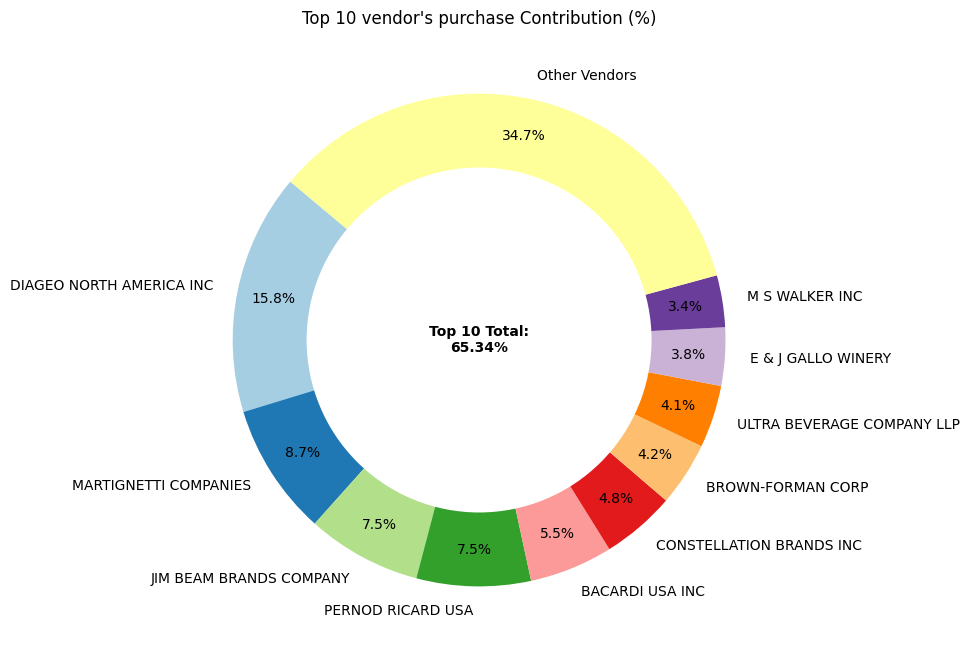

In [105]:
vendors=list(top_vendors['VendorName'].values)
purchase_contributions=list(top_vendors['PurchaseContribution%'].values)

total_contribution=sum(purchase_contributions)
remaining_contribution=100-total_contribution

# Append "other vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)


# Donut chart
fig, ax= plt.subplots(figsize=(8,8))
wedges, texts,autotexts =ax.pie(purchase_contributions,labels=vendors,autopct='%1.1f%%',startangle=140,pctdistance=0.85,colors=plt.cm.Paired.colors)

# Draw a white circle in the center to create a "donut" effect
centre_circle=plt.Circle((0,0),0.70,fc='white')
fig.gca().add_artist(centre_circle)

# Add total contribution annotation in the center
plt.text(0,0,f"Top 10 Total:\n{total_contribution:.2f}%",fontsize=10,fontweight='bold',ha='center',va='center')

plt.title("Top 10 vendor's purchase Contribution (%)")
plt.show()

**Does purchasing in bulk reduce the unit price, and what is the optimal purchase volume for cost saving?**

In [106]:
df['UnitPurchasePrice']=df['TotalPurchaseDollars']/df['TotalPurchaseQuantity']

In [107]:
df['OrderSize']=pd.qcut(df['TotalPurchaseQuantity'],q=3,labels=['Small','Medium','Large'])

In [108]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

C:\Users\Ashish Panchal\AppData\Local\Temp\ipykernel_3384\1505448859.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('OrderSize')[['UnitPurchasePrice']].mean()


,UnitPurchasePrice
OrderSize,
Small,43.776954
Medium,17.894005
Large,11.308807


C:\Users\Ashish Panchal\AppData\Local\Temp\ipykernel_3384\567960540.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='OrderSize',y='UnitPurchasePrice',palette='Set2')


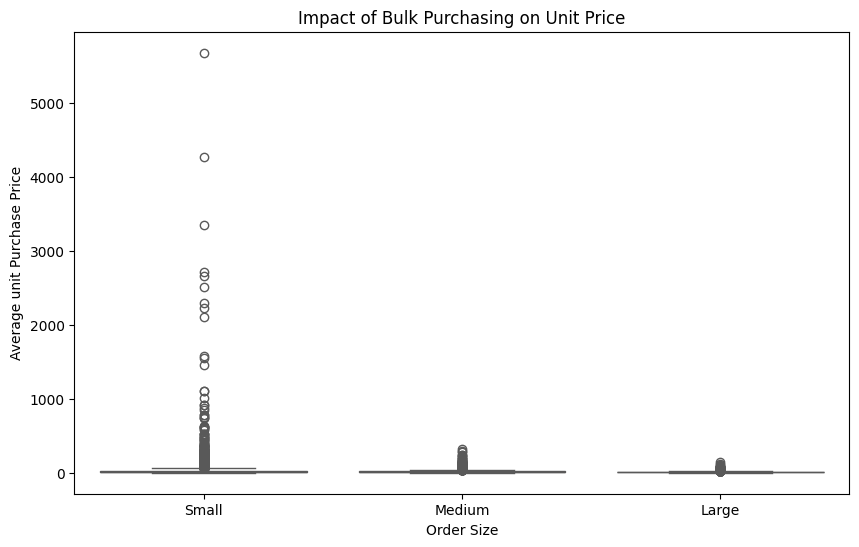

In [109]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='OrderSize',y='UnitPurchasePrice',palette='Set2')
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average unit Purchase Price")
plt.show()

* Vendors buying in bulk get the lowest unit price, means higher margin if they can manage inventory efficiently.
* This suggest that bulk pricing strategies successfully encourage vendors to pruchase in larger volumes, leading to higher overall sales.


**Which vendors have low inventory turnover, indicating excess stock and slow-moving products?**

In [110]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover',ascending=True).head(10)

,StockTurnover
VendorName,
AAPER ALCOHOL & CHEMICAL CO,0.000000
ADAMBA IMPORTS INTL INC,0.000000
MILTONS DISTRIBUTING CO,0.000000
LAUREATE IMPORTS CO,0.000000
HIGHLAND WINE MERCHANTS LLC,0.031746
PHILLIPS PRODUCTS CO.,0.045455
TRUETT HURST,0.083333
DELICATO VINEYARDS INC,0.104167
R.P.IMPORTS INC,0.111111


**How much capital is locked in unsold inventory per vendor, and which vendors contribute the most to it ?**

In [111]:
df['UnsoldInventoryValue']=(df['TotalPurchaseDollars']-df['TotalSalesQuantity'])*df['PurchasePrice']
df['UnsoldInventoryValue'].sum()

np.float64(5788990541.427104)

In [112]:
# Aggregate Capital Locked per Vendor
inventory_value_per_vendor=df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

# Sort vendors with the highest locked capital
inventory_value_per_vendor=inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue",ascending=False)


In [113]:
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
28,DIAGEO NORTH AMERICA INC,1.104489e+09
74,PERNOD RICARD USA,5.045694e+08
63,MARTIGNETTI COMPANIES,4.225514e+08
50,JIM BEAM BRANDS COMPANY,4.118109e+08
67,MOET HENNESSY USA INC,4.081123e+08
114,ULTRA BEVERAGE COMPANY LLP,3.850079e+08
8,BACARDI USA INC,2.805461e+08
14,BROWN-FORMAN CORP,2.652056e+08
83,REMY COINTREAU USA INC,2.574042e+08
125,WILLIAM GRANT & SONS INC,2.011499e+08


**What is the 95% confidence intervals for profit margins of top-performing and low-performing vendors?**

In [114]:
top_threshold=df["TotalSalesDollars"].quantile(0.75)
low_threshold=df['TotalSalesDollars'].quantile(0.25)


In [115]:
top_vendors=df[df['TotalSalesDollars'] >= top_threshold]['ProfitMargin'].dropna()
low_vendors=df[df['TotalSalesDollars'] <= low_sales_threshold]['ProfitMargin'].dropna()

In [116]:
low_vendors

2147     -9639.298573
2462     -5586.342207
3676     -4060.770264
3981    -11815.319477
4277     -1706.258037
             ...     
10687       91.724138
10688       98.218093
10689       62.626263
10690       99.487018
10691       99.583040
Name: ProfitMargin, Length: 1430, dtype: float64

In [117]:
def confidence_interval(data,confidence=0.95):
    mean_value=np.mean(data)
    std_err=np.std(data,ddof=1)/np.sqrt(len(data)) # standard error
    t_critical=stats.t.ppf((1+confidence)/2,df=len(data)-1)
    margin_of_error=t_critical*std_err
    return mean_value,mean_value-margin_of_error,mean_value+margin_of_error


Top Vendors 95% CI : (64.76, 65.28), Mean : 65.02
Low Vendors 95% CI : (-97.03, -36.66), Mean : -66.85


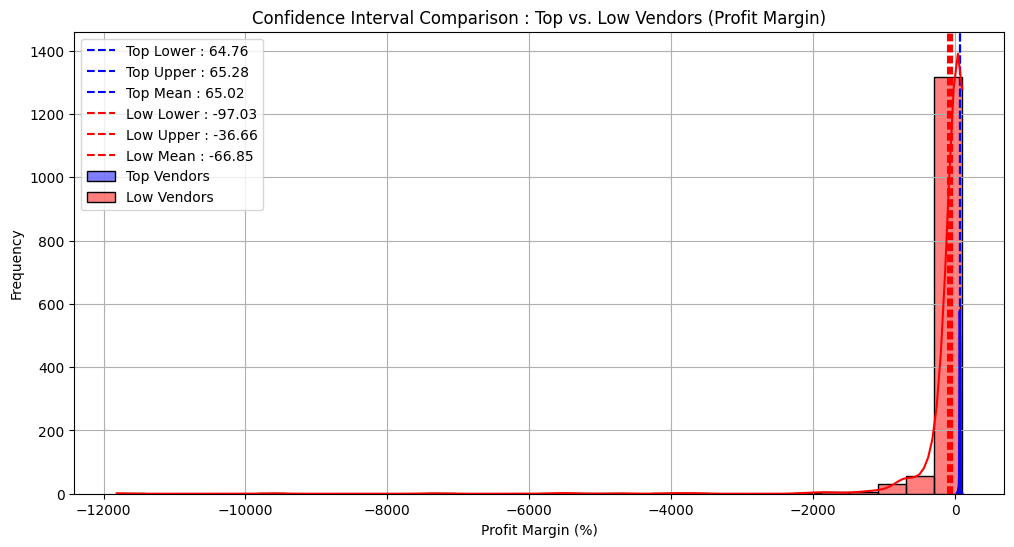

In [118]:
top_mean,top_lower,top_upper=confidence_interval(top_vendors)
low_mean,low_lower,low_upper=confidence_interval(low_vendors)

print(f"Top Vendors 95% CI : ({top_lower:.2f}, {top_upper:.2f}), Mean : {top_mean:.2f}")
print(f"Low Vendors 95% CI : ({low_lower:.2f}, {low_upper:.2f}), Mean : {low_mean:.2f}")

plt.figure(figsize=(12,6))

#Top Vendors plot
sns.histplot(top_vendors,kde=True,color="blue",bins=30,alpha=0.5,label="Top Vendors")
plt.axvline(top_lower,color='blue',linestyle="--",label=f"Top Lower : {top_lower:.2f}")
plt.axvline(top_upper,color='blue',linestyle="--",label=f"Top Upper : {top_upper:.2f}")
plt.axvline(top_mean,color="blue",linestyle="--",label=f"Top Mean : {top_mean:.2f}")



# Low Vendors plot

sns.histplot(low_vendors,kde=True,color="red",bins=30,alpha=0.5,label="Low Vendors")
plt.axvline(low_lower,color='red',linestyle="--",label=f"Low Lower : {low_lower:.2f}")
plt.axvline(low_upper,color='red',linestyle="--",label=f"Low Upper : {low_upper:.2f}")
plt.axvline(low_mean,color="red",linestyle="--",label=f"Low Mean : {low_mean:.2f}")


# Finalize plot
plt.title("Confidence Interval Comparison : Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

#### Hypothesis Testing

Is there a significant difference in profit margins between top-performing and low-performing vendors?



**Null Hypothesis** : There is no significant difference in the mean profit margin of top-performing and low-performing vendors.

**Alternative Hypothesis**  : The mean profit margins of top-performing and low-performing vendors are significantly different.

In [119]:
top_threshold=df["TotalSalesDollars"].quantile(0.75)
low_threshold=df['TotalSalesDollars'].quantile(0.25)

top_vendors=df[df['TotalSalesDollars'] >= top_threshold]['ProfitMargin'].dropna()
low_vendors=df[df['TotalSalesDollars'] <= low_sales_threshold]['ProfitMargin'].dropna()

# Perform two sample t-test
t_stat,p_value=ttest_ind(top_vendors,low_vendors,equal_var=False)

#Result
print(f"T-Statistic : {t_stat:.4f}, P-Value : {p_value:.4f}")
if p_value<0.05:
    print("Reject Null Hypothesis")
    print("There is significant difference in profit margin between top and low performing vendors.")
else:
    print("Fail to reject Null Hypothesis : No significant difference in profit margins.")


T-Statistic : 8.5697, P-Value : 0.0000
Reject Null Hypothesis
There is significant difference in profit margin between top and low performing vendors.
